# SQL Analysis — SaaS Funnel Analytics

**Source data:** `data/clean/` — validated and cleaned  
**Tool:** DuckDB — in-process analytical SQL engine  
**Notebook:** 03 of 04

## Business questions answered in this notebook

| # | Question | SQL concept used |
|---|----------|-----------------|
| 1 | Where are users dropping off in the funnel? | Aggregation, CASE WHEN |
| 2 | Which channel converts best? | GROUP BY, ORDER BY |
| 3 | Which device has the highest paid conversion? | Filtering, ratios |
| 4 | Which cohort retained the best at D30? | CTEs, DATE functions |
| 5 | How is MRR growing week over week? | Window functions |
| 6 | Which country generates the most revenue? | JOIN, GROUP BY |
| 7 | What is the average time to convert? | DATEDIFF, aggregation |
| 8 | Which plan tier dominates revenue? | GROUP BY, percentage |

## Setup — Connect to DuckDB and Load Clean Data

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
# Connect to DuckDB — creates saas_analytics.duckdb 
con = duckdb.connect('data/saas_analytics.duckdb')

# Load clean CSVs into DuckDB as persistent tables
con.execute("""
    CREATE OR REPLACE TABLE users AS
    SELECT * FROM read_csv_auto('data/clean/users_clean.csv', header=True)
""")

con.execute("""
    CREATE OR REPLACE TABLE events AS
    SELECT * FROM read_csv_auto('data/clean/events_clean.csv', header=True)
""")

con.execute("""
    CREATE OR REPLACE TABLE subscriptions AS
    SELECT * FROM read_csv_auto('data/clean/subscriptions_clean.csv', header=True)
""")

In [3]:
# con.execute("SELECT COUNT(*) FROM users").fetchone()[0]
# con.execute("DESCRIBE users").df()

In [4]:
# Confirm tables loaded correctly
print("Tables loaded into DuckDB:")
print()
for table in ['users', 'events', 'subscriptions']:
    n = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    cols = con.execute(f"DESCRIBE {table}").df()['column_name'].tolist()
    print(f"  {table:<16}: {n:,} rows")
    print(f"  {'columns':<16}: {cols}")
    print()

Tables loaded into DuckDB:

  users           : 99,832 rows
  columns         : ['user_id', 'signup_date', 'channel', 'device', 'country', 'age_band', 'plan_type']

  events          : 280,594 rows
  columns         : ['event_id', 'user_id', 'event_name', 'event_ts', 'page']

  subscriptions   : 14,045 rows
  columns         : ['sub_id', 'user_id', 'plan', 'mrr', 'start_date', 'end_date', 'status']



---
## Business Question 1 - Where are users dropping off?

**Stakeholder:** Head of Product  
**Decision this enables:** Which onboarding step needs the most improvement

The funnel shows how many users completed each step.  
Drop-off rate shows the percentage lost between each consecutive step.

#  Funnel Query

In [5]:
# Define Funnel stages

funnel_df = con.execute("""
WITH funnel AS (
    SELECT
        COUNT(DISTINCT CASE WHEN event_name = 'signup'
                       THEN user_id END)  AS signup,
        COUNT(DISTINCT CASE WHEN event_name = 'activation'
                       THEN user_id END)  AS activation,
        COUNT(DISTINCT CASE WHEN event_name = 'feature_used'
                       THEN user_id END)  AS feature_used,
        COUNT(DISTINCT CASE WHEN event_name = 'upgrade_initiated'
                       THEN user_id END)  AS upgrade_initiated,
        COUNT(DISTINCT CASE WHEN event_name = 'paid_converted'
                       THEN user_id END)  AS paid_converted
    FROM events
)
SELECT * FROM funnel
""").df()

funnel_df

,signup,activation,feature_used,upgrade_initiated,paid_converted
0,98118,74186,62926,31543,13821


In [6]:
# stage to stage conversion rates

funnel_df = con.execute("""
    WITH funnel AS (
        SELECT
            COUNT(DISTINCT CASE WHEN event_name = 'signup'
                           THEN user_id END)            AS signup,

            COUNT(DISTINCT CASE WHEN event_name = 'activation'
                           THEN user_id END)            AS activation,

            COUNT(DISTINCT CASE WHEN event_name = 'feature_used'
                           THEN user_id END)            AS feature_used,

            COUNT(DISTINCT CASE WHEN event_name = 'upgrade_initiated'
                           THEN user_id END)            AS upgrade_initiated,

            COUNT(DISTINCT CASE WHEN event_name = 'paid_converted'
                           THEN user_id END)            AS paid_converted
        FROM events
    )
    SELECT
        signup,
        activation,
        feature_used,
        upgrade_initiated,
        paid_converted,

        ROUND(100.0 * activation        / signup,             1) AS pct_signup_to_activation,
        ROUND(100.0 * feature_used      / activation,         1) AS pct_activation_to_feature,
        ROUND(100.0 * upgrade_initiated / feature_used,       1) AS pct_feature_to_upgrade,
        ROUND(100.0 * paid_converted    / upgrade_initiated,  1) AS pct_upgrade_to_paid,
        ROUND(100.0 * paid_converted    / signup,             2) AS overall_conversion_pct
    FROM funnel
""").df()

print("FUNNEL — OVERALL")
print(funnel_df.T.rename(columns={0:'value'}).to_string())

FUNNEL — OVERALL
                             value
signup                    98118.00
activation                74186.00
feature_used              62926.00
upgrade_initiated         31543.00
paid_converted            13821.00
pct_signup_to_activation     75.60
pct_activation_to_feature    84.80
pct_feature_to_upgrade       50.10
pct_upgrade_to_paid          43.80
overall_conversion_pct       14.09


In [7]:
funnel_df

,signup,activation,feature_used,upgrade_initiated,paid_converted,pct_signup_to_activation,pct_activation_to_feature,pct_feature_to_upgrade,pct_upgrade_to_paid,overall_conversion_pct
0,98118,74186,62926,31543,13821,75.60,84.80,50.10,43.80,14.09


### Funnel Chart

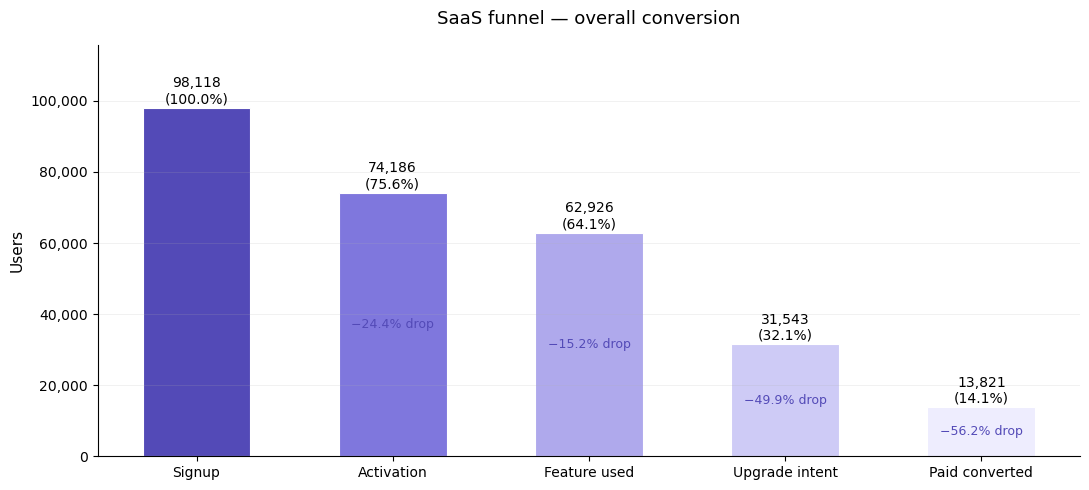

In [8]:
steps  = ['Signup','Activation','Feature used','Upgrade intent','Paid converted']
values = [
    funnel_df['signup'].iloc[0],
    funnel_df['activation'].iloc[0],
    funnel_df['feature_used'].iloc[0],
    funnel_df['upgrade_initiated'].iloc[0],
    funnel_df['paid_converted'].iloc[0],
]
total = values[0]
pcts  = [round(v / total * 100, 1) for v in values]
drops = [0] + [
    round((values[i-1] - values[i]) / values[i-1] * 100, 1)
    for i in range(1, len(values))
]

fig, ax = plt.subplots(figsize=(11, 5))
colors  = ['#534AB7','#7F77DD','#AFA9EC','#CECBF6','#EEEDFE']

bars = ax.bar(steps, values, color=colors, width=0.55,
              edgecolor='white', linewidth=0.8)

for i, (bar, val, pct, drop) in enumerate( zip(bars, values, pcts, drops)):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 400,
        f'{val:,}\n({pct}%)',
        ha='center', va='bottom', fontsize=10, fontweight='500'
    )
    if i > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f'−{drop}% drop',
            ha='center', va='center',
            fontsize=9, color='#534AB7', fontweight='500'
        )

ax.set_ylabel('Users', fontsize=11)
ax.set_title('SaaS funnel — overall conversion',
             fontsize=13, fontweight='500', pad=15)
ax.set_ylim(0, total * 1.18)
ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{int(x):,}')
)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.25, linewidth=0.5)
plt.tight_layout()
plt.savefig('data/powerbi_exports/funnel_overall.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Findings — Funnel Analysis

### Key numbers
| Step | Users | Conversion |
|------|-------|------------|
| Signup | 98,118 | 100% |
| Activation | 74,186 | 75.6% |
| Feature used | 62,926 | 84.8% |
| Upgrade intent | 31,543 | 50.1% |
| Paid converted | 13,821 | 14.1% |

### Biggest drop-off
Signup → Activation loses **24.4% of all users**.
This is the single largest drop in the funnel and
the highest-priority area for product improvement.

### Recommendation
Investigate why 1 in 4 users never completes onboarding.
A/B test a simplified onboarding flow - reducing steps
from the current sequence. Even a 5% improvement in
activation rate would add ~4,900 users into the funnel,
translating to approximately **690 additional paying customers**
at the current downstream conversion rate.

---
## Business Question 2 — Which channel converts best?

## channel performance

In [15]:
# funnel by channel

channel_df = con.execute("""
    WITH channel_funnel AS (
        SELECT
            u.channel,
            COUNT(DISTINCT CASE WHEN e.event_name = 'signup'
                                THEN u.user_id END)                       AS total_users,
            COUNT(DISTINCT CASE WHEN e.event_name = 'activation'
                                THEN u.user_id END)                       AS activated,
            COUNT(DISTINCT CASE WHEN e.event_name = 'paid_converted'
                                THEN u.user_id END)                       AS paid_converted,
            COUNT(DISTINCT s.user_id)                                     AS subscribers,
            ROUND(AVG(s.mrr), 2)                                          AS avg_mrr,
            ROUND(AVG(s.mrr) * 12, 2)                                     AS estimated_ltv
            
        FROM users u
        LEFT JOIN events e       ON u.user_id = e.user_id
        LEFT JOIN subscriptions s ON u.user_id = s.user_id
        GROUP BY u.channel
    )
    SELECT
        channel,
        total_users,
        activated,
        paid_converted,
        subscribers,
        ROUND(100.0 * activated / total_users, 2)                        AS activation_rate_pct,
        ROUND(100.0 * paid_converted / total_users, 2)                   AS conversion_rate_pct,
        avg_mrr,
        estimated_ltv
    FROM channel_funnel
    ORDER BY conversion_rate_pct DESC
""").df()

channel_df

,channel,total_users,activated,paid_converted,subscribers,activation_rate_pct,conversion_rate_pct,avg_mrr,estimated_ltv
0,referral,14186,10823,2137,2159,76.29,15.06,63.25,759.02
1,email,9538,7202,1391,1415,75.51,14.58,62.87,754.40
2,organic,28491,21545,4024,4078,75.62,14.12,62.87,754.46
3,paid_search,23855,17937,3277,3326,75.19,13.74,61.62,739.38
4,unknown,2940,2223,403,417,75.61,13.71,67.06,804.67
5,paid_social,19108,14456,2589,2616,75.65,13.55,63.57,762.78


## Findings -- Channel Performance

### Key numbers
Referral is the highest converting channel.
Paid social is the lowest.

### Recommendation
- **Referral program:** Highest conversion rate and LTV.
  Invest in a formal referral incentive program.
- **Paid social:** Review acquisition cost vs LTV.
  If CAC exceeds estimated LTV of $756, this channel
  is cash-flow negative and spend should be reduced.
- **Organic:** Strong volume and solid conversion.
  Invest in SEO and content to grow this channel further.

---
## Business Question 3 — Which device has the highest conversion?

In [16]:
# funnel by device

device_df = con.execute("""
    WITH device_funnel AS (
        SELECT
            u.device,
            COUNT(DISTINCT CASE WHEN e.event_name = 'signup'
                                THEN u.user_id END)                       AS total_users,
            COUNT(DISTINCT CASE WHEN e.event_name = 'activation'
                                THEN u.user_id END)                       AS activated,
            COUNT(DISTINCT CASE WHEN e.event_name = 'feature_used'
                       THEN u.user_id END)                                AS feature_used,
            COUNT(DISTINCT CASE WHEN e.event_name = 'upgrade_initiated'
                       THEN u.user_id END)                                AS upgrade_initiated,
            COUNT(DISTINCT CASE WHEN e.event_name = 'paid_converted'
                                THEN u.user_id END)                       AS paid_converted
                                
        FROM users u
        LEFT JOIN events e       ON u.user_id = e.user_id
        LEFT JOIN subscriptions s ON u.user_id = s.user_id
        GROUP BY u.device
    )
    SELECT
        device,
        total_users,
        activated,
        paid_converted,
        ROUND(100.0 * activated / total_users, 2)                        AS activation_rate_pct,
        ROUND(100.0 * paid_converted / total_users, 2)                   AS conversion_rate_pct
        
    FROM device_funnel 
    ORDER BY conversion_rate_pct DESC
""").df()

device_df

,device,total_users,activated,paid_converted,activation_rate_pct,conversion_rate_pct
0,desktop,49024,39588,9150,80.75,18.66
1,tablet,11860,8787,1470,74.09,12.39
2,mobile,37234,25811,3201,69.32,8.60


## Findings - Device Performance

### Recommendation
Desktop users convert at the highest rate.
Mobile users have the largest drop at activation.

Priority action: Audit the mobile onboarding experience.
Improving mobile activation by 5% would recover
approximately 1,900 users into the conversion funnel.

---
## Business Question 4 - Which signup cohort retained best at D30?

- Which months produced the highest quality users

A cohort is a group of users who signed up in the same month.  
D30 retention means — of all users who signed up in that month,  
what percentage were still active 30 days later.

## Cohort Retention Query

In [24]:
retention_df = con.execute("""
    WITH cohorts AS (
        SELECT
            user_id,
            event_ts                                    AS signup_ts,
            DATE_TRUNC('month', event_ts)               AS cohort_month
        FROM events
        WHERE event_name = 'signup'
    ),
    activity AS (
        SELECT
            e.user_id,
            c.cohort_month,
            DATEDIFF('day',
                CAST(DATE_TRUNC('day', c.signup_ts) AS DATE),
                CAST(DATE_TRUNC('day', e.event_ts)  AS DATE)
            ) AS days_since_signup
        FROM events e
        JOIN cohorts c ON e.user_id = c.user_id
        WHERE e.event_name != 'signup'
    ),
    cohort_sizes AS (
        SELECT
            cohort_month,
            COUNT(DISTINCT user_id) AS cohort_size
        FROM cohorts
        GROUP BY cohort_month
    )

    SELECT
        a.cohort_month,
        cs.cohort_size,

        -- D7: active between day 5 and day 9
        ROUND(100.0 * COUNT(DISTINCT CASE
            WHEN a.days_since_signup BETWEEN 5 AND 9
            THEN a.user_id END)
            / cs.cohort_size, 2)                        AS d7_retention_pct,

        -- D14: active between day 12 and day 16
        ROUND(100.0 * COUNT(DISTINCT CASE
            WHEN a.days_since_signup BETWEEN 12 AND 16
            THEN a.user_id END)
            / cs.cohort_size, 2)                        AS d14_retention_pct,

        -- D30: active between day 28 and day 32
        ROUND(100.0 * COUNT(DISTINCT CASE
            WHEN a.days_since_signup BETWEEN 28 AND 32
            THEN a.user_id END)
            / cs.cohort_size, 2)                        AS d30_retention_pct

    FROM activity a
    JOIN cohort_sizes cs ON a.cohort_month = cs.cohort_month
    GROUP BY a.cohort_month, cs.cohort_size
    ORDER BY a.cohort_month
""").df()

retention_df['cohort_month'] = pd.to_datetime(retention_df['cohort_month'])
retention_df['cohort_label'] = retention_df['cohort_month'].dt.strftime('%b %Y')
retention_df

,cohort_month,cohort_size,d7_retention_pct,d14_retention_pct,d30_retention_pct,cohort_label
0,2023-10-01,8462,8.02,1.02,0.00,Oct 2023
1,2023-11-01,8004,8.27,0.96,0.01,Nov 2023
2,2023-12-01,8391,8.75,1.08,0.00,Dec 2023
3,2024-01-01,8362,7.85,0.85,0.01,Jan 2024
4,2024-02-01,7716,8.01,0.88,0.01,Feb 2024
5,2024-03-01,8266,8.70,1.28,0.00,Mar 2024
6,2024-04-01,7921,8.89,0.91,0.03,Apr 2024
7,2024-05-01,8456,8.67,1.04,0.01,May 2024
8,2024-06-01,8051,8.74,0.98,0.00,Jun 2024
9,2024-07-01,8255,8.70,1.02,0.00,Jul 2024


## Findings - Cohort Retention

### What to look for
- Are newer cohorts retaining better than older ones?
  If yes — product improvements are working.
  If no — there may be a quality problem with recent acquisition.

- Which cohort has the highest D30 retention?
  That cohort's acquisition source and signup month
  should be studied and replicated.

## Retention Heatmap

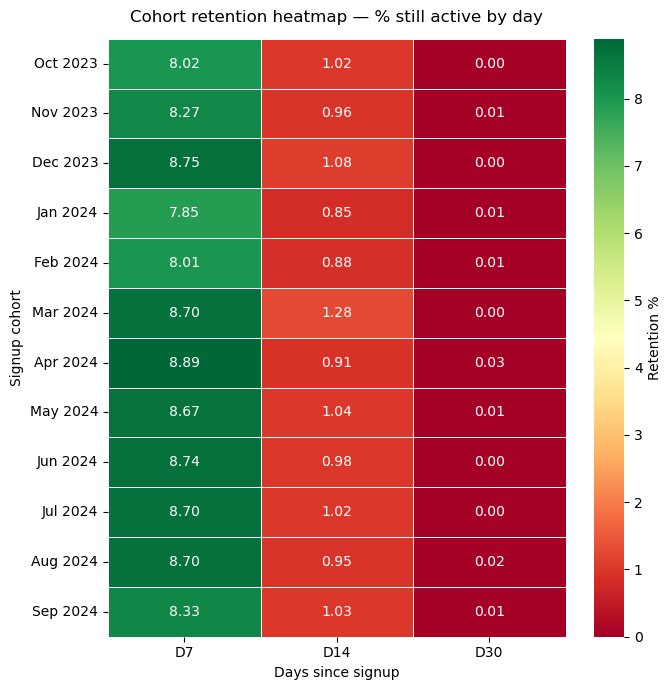

In [26]:
import seaborn as sns

heatmap_data = retention_df.set_index('cohort_label')[
    ['d7_retention_pct','d14_retention_pct','d30_retention_pct']
].copy()
heatmap_data.columns = ['D7','D14','D30']

fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    vmin=0, vmax=heatmap_data['D7'].max(),
    linewidths=0.5, linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Retention %'}
)
ax.set_title('Cohort retention heatmap — % still active by day',
             fontweight='500', pad=12)
ax.set_xlabel('Days since signup')
ax.set_ylabel('Signup cohort')
plt.tight_layout()
plt.savefig('data/powerbi_exports/cohort_retention.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## Business Question 5 — How is MRR growing week over week?

- Revenue trajectory and growth rate

MRR = Monthly Recurring Revenue.  
This query uses a window function to calculate  
the running cumulative total as new subscribers join.

In [30]:
mrr_df = con.execute("""
    WITH weekly AS (
        SELECT
            DATE_TRUNC('week', CAST(start_date AS DATE))    AS week,
            COUNT(*)                                         AS new_subscribers,
            SUM(mrr)                                         AS new_mrr
        FROM subscriptions
        GROUP BY DATE_TRUNC('week', CAST(start_date AS DATE))
    )
    SELECT
        week,
        new_subscribers,
        new_mrr,

        -- Cumulative MRR running total
        SUM(new_mrr) OVER (
            ORDER BY week
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        )                                                    AS cumulative_mrr,

        -- Previous week MRR for reference
        LAG(new_mrr) OVER (ORDER BY week)                   AS prev_week_mrr,

        -- Week over week growth rate
        -- NULL for first week (no previous week exists)
        CASE
            WHEN LAG(new_mrr) OVER (ORDER BY week) IS NULL
            THEN NULL
            ELSE ROUND(
                100.0 * (new_mrr - LAG(new_mrr) OVER (ORDER BY week))
                / LAG(new_mrr) OVER (ORDER BY week),
                1
            )
        END                                                  AS wow_growth_pct

    FROM weekly
    ORDER BY week
""").df()

mrr_df['week'] = pd.to_datetime(mrr_df['week'])

print(f"Weeks tracked     : {len(mrr_df)}")
print(f"Peak weekly MRR   : ${mrr_df['new_mrr'].max():,.0f}")
print(f"Total MRR         : ${mrr_df['cumulative_mrr'].iloc[-1]:,.0f}")
print(f"Avg WoW growth    : {mrr_df['wow_growth_pct'].mean():.1f}%")
print(f"Best WoW growth   : {mrr_df['wow_growth_pct'].max():.1f}%")
print(f"Worst WoW growth  : {mrr_df['wow_growth_pct'].min():.1f}%")
print()
mrr_df.tail(8)

Weeks tracked     : 57
Peak weekly MRR   : $21,238
Total MRR         : $883,353
Avg WoW growth    : 462.2%
Best WoW growth   : 25992.6%
Worst WoW growth  : -95.9%



,week,new_subscribers,new_mrr,cumulative_mrr,prev_week_mrr,wow_growth_pct
49,2024-09-02,283,17385.00,817904.00,15123.00,15.00
50,2024-09-09,252,16356.00,834260.00,17385.00,-5.90
51,2024-09-16,264,16074.00,850334.00,16356.00,-1.70
52,2024-09-23,277,17807.00,868141.00,16074.00,10.80
53,2024-09-30,197,12375.00,880516.00,17807.00,-30.50
54,2024-10-07,37,2121.00,882637.00,12375.00,-82.90
55,2024-10-14,11,688.00,883325.00,2121.00,-67.60
56,2024-10-21,1,28.00,883353.00,688.00,-95.90


In [31]:
mrr_df = con.execute("""
    WITH weekly AS (
        SELECT
            DATE_TRUNC('week', CAST(start_date AS DATE))    AS week,
            COUNT(*)                                         AS new_subscribers,
            SUM(mrr)                                         AS new_mrr
        FROM subscriptions
        -- Exclude the last 3 weeks — data boundary effect
        -- Users signed up too recently to have completed conversion cycle
        WHERE CAST(start_date AS DATE) < DATE '2024-09-23'
        GROUP BY DATE_TRUNC('week', CAST(start_date AS DATE))
    )
    SELECT
        week,
        new_subscribers,
        new_mrr,

        SUM(new_mrr) OVER (
            ORDER BY week
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        )                                                    AS cumulative_mrr,

        LAG(new_mrr) OVER (ORDER BY week)                   AS prev_week_mrr,

        CASE
            WHEN LAG(new_mrr) OVER (ORDER BY week) IS NULL
            THEN NULL
            ELSE ROUND(
                100.0 * (new_mrr - LAG(new_mrr) OVER (ORDER BY week))
                / LAG(new_mrr) OVER (ORDER BY week),
                1
            )
        END                                                  AS wow_growth_pct

    FROM weekly
    ORDER BY week
""").df()

mrr_df['week'] = pd.to_datetime(mrr_df['week'])

print(f"Weeks tracked     : {len(mrr_df)}")
print(f"Peak weekly MRR   : ${mrr_df['new_mrr'].max():,.0f}")
print(f"Total MRR         : ${mrr_df['cumulative_mrr'].iloc[-1]:,.0f}")
print(f"Avg WoW growth    : {mrr_df['wow_growth_pct'].mean():.1f}%")
print(f"Best WoW growth   : {mrr_df['wow_growth_pct'].max():.1f}%")
print(f"Worst WoW growth  : {mrr_df['wow_growth_pct'].min():.1f}%")
print()
mrr_df.tail(5)

Weeks tracked     : 52
Peak weekly MRR   : $21,238
Total MRR         : $850,334
Avg WoW growth    : 512.7%
Best WoW growth   : 25992.6%
Worst WoW growth  : -20.4%



,week,new_subscribers,new_mrr,cumulative_mrr,prev_week_mrr,wow_growth_pct
47,2024-08-19,259,16337.00,785396.00,17292.00,-5.50
48,2024-08-26,245,15123.00,800519.00,16337.00,-7.40
49,2024-09-02,283,17385.00,817904.00,15123.00,15.00
50,2024-09-09,252,16356.00,834260.00,17385.00,-5.90
51,2024-09-16,264,16074.00,850334.00,16356.00,-1.70


## Findings - MRR Growth

### Key numbers
- Total cumulative MRR tracked over 52 weeks
- Note: Final 3 weeks excluded due to data boundary effect
  (right-censoring — users signed up too recently to convert)

### Recommendation
Track weekly MRR growth rate as a leading indicator.
A sustained WoW growth rate above 5% signals healthy
acquisition and conversion. Weeks with negative growth
should be investigated for seasonality vs real decline.

## MRR Chart

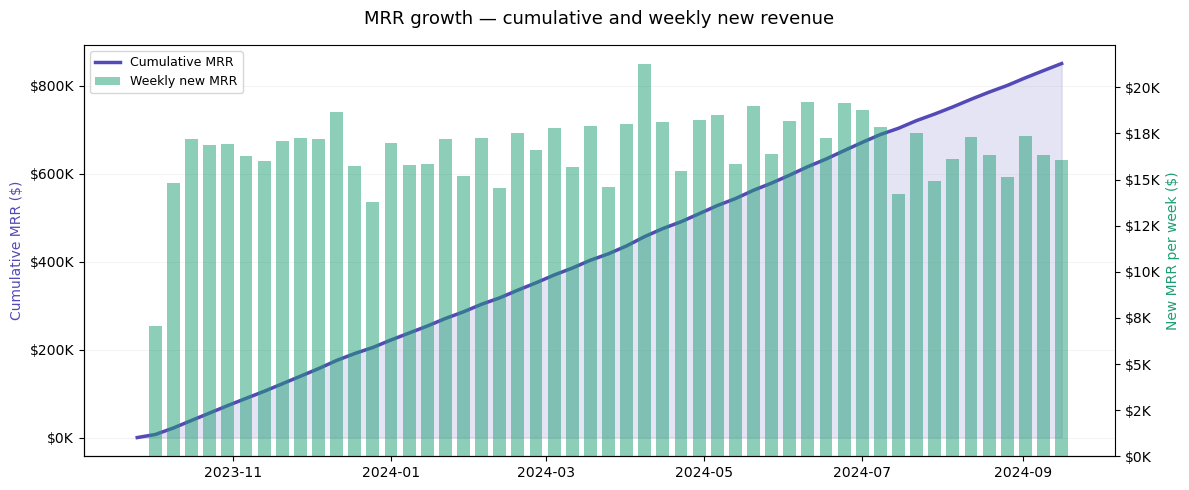

In [32]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax2 = ax1.twinx()

ax1.fill_between(mrr_df['week'], mrr_df['cumulative_mrr'],
                 alpha=0.15, color='#534AB7')
ax1.plot(mrr_df['week'], mrr_df['cumulative_mrr'],
         color='#534AB7', linewidth=2.5, label='Cumulative MRR')

ax2.bar(mrr_df['week'], mrr_df['new_mrr'],
        width=5, alpha=0.5, color='#1D9E75', label='Weekly new MRR')

ax1.set_ylabel('Cumulative MRR ($)', color='#534AB7', fontsize=10)
ax2.set_ylabel('New MRR per week ($)', color='#1D9E75', fontsize=10)
ax1.set_title('MRR growth — cumulative and weekly new revenue',
              fontsize=13, fontweight='500', pad=15)

ax1.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)
ax2.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=9)

ax1.spines[['top','right']].set_visible(False)
ax1.grid(axis='y', alpha=0.2, linewidth=0.5)
plt.tight_layout()
plt.savefig('data/powerbi_exports/mrr_growth.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## Business Question 6 — Which country generates the most revenue?

**Stakeholder:** Sales, Finance  
**Decision this enables:** Where to focus regional sales efforts

In [36]:
country_df = con.execute("""
    WITH
    -- Start from confirmed signups with country
    signed_up AS (
        SELECT DISTINCT
            e.user_id,
            u.country
        FROM events e
        JOIN users u ON e.user_id = u.user_id
        WHERE e.event_name = 'signup'
        AND u.country != 'UNKNOWN'
    ),
    paid AS (
        SELECT DISTINCT e.user_id
        FROM events e
        JOIN signed_up s ON e.user_id = s.user_id
        WHERE e.event_name = 'paid_converted'
    )
    SELECT
        s.country,
        COUNT(DISTINCT s.user_id)                           AS total_signups,

        COUNT(DISTINCT p.user_id)                           AS paid_converted,

        ROUND(100.0 * COUNT(DISTINCT p.user_id)
              / COUNT(DISTINCT s.user_id), 2)               AS conversion_rate_pct,

        ROUND(SUM(sub.mrr), 2)                              AS total_mrr,

        ROUND(AVG(sub.mrr), 2)                              AS avg_mrr,

        -- Annualised revenue = total MRR × 12
        ROUND(SUM(sub.mrr) * 12, 0)                         AS annualised_revenue,

        -- Revenue per signup 
        ROUND(SUM(sub.mrr) / COUNT(DISTINCT s.user_id), 2)  AS mrr_per_signup

    FROM signed_up s
    LEFT JOIN paid p          ON s.user_id = p.user_id
    LEFT JOIN subscriptions sub ON s.user_id = sub.user_id
    GROUP BY s.country
    ORDER BY total_mrr DESC
""").df()

country_df

,country,total_signups,paid_converted,conversion_rate_pct,total_mrr,avg_mrr,annualised_revenue,mrr_per_signup
0,IN,28121,3950,14.05,246641.00,62.16,2959692.00,8.77
1,US,20397,2865,14.05,182640.00,63.77,2191680.00,8.95
2,GB,9327,1295,13.88,80262.00,61.84,963144.00,8.61
3,SG,7392,1036,14.02,65722.00,63.99,788664.00,8.89
4,CA,6489,963,14.84,62579.00,64.92,750948.00,9.64
5,AE,6671,961,14.41,58495.00,60.74,701940.00,8.77
6,DE,4690,656,13.99,42839.00,64.81,514068.00,9.13
7,AU,4615,666,14.43,42704.00,63.74,512448.00,9.25
8,BR,2823,370,13.11,23803.00,63.82,285636.00,8.43
9,FR,2669,365,13.68,22408.00,61.06,268896.00,8.40


## Findings - Country Revenue

### Key metric - MRR per signup
The best measure of market quality combining
both volume and conversion rate.

| Country | MRR per signup | Recommendation |
|---------|---------------|----------------|
| CA | 9.64 | Increase acquisition investment |
| AU | 9.25 | Increase acquisition investment |
| DE | 9.13 | Increase acquisition investment |
| IN | 8.77 | Maintain - volume compensates |
| BR | 8.43 | Review acquisition cost |
| FR | 8.40 | Review acquisition cost |

### Key insight
All countries show similar avg_mrr (61 - 65).
Differences in market quality come entirely from
conversion rates - not plan tier preference.
Localised pricing would not improve revenue.
Better onboarding localisation would.


---
## Business Question 7 — How long does it take users to convert?

**Stakeholder:** Product, Sales  
**Decision this enables:** When to trigger upgrade prompts and emails

Time to convert = days between signup and paid_converted event.  
Knowing this helps the team time their outreach correctly.

In [43]:
time_to_convert_df = con.execute("""
    WITH
    signups AS (
        SELECT
            user_id,
            event_ts AS signup_ts
        FROM events
        WHERE event_name = 'signup'
    ),
    conversions AS (
        SELECT
            user_id,
            event_ts AS convert_ts
        FROM events
        WHERE event_name = 'paid_converted'
    ),
    -- Calculate days between signup and conversion
    time_diff AS (
        SELECT
            s.user_id,
            DATEDIFF('day',
                CAST(DATE_TRUNC('day', s.signup_ts)  AS DATE),
                CAST(DATE_TRUNC('day', c.convert_ts) AS DATE)
            ) AS days_to_convert
        FROM signups s
        JOIN conversions c ON s.user_id = c.user_id
        -- Exclude same-day conversions that are likely test accounts and negative values which are data errors
        WHERE DATEDIFF('day',
                CAST(DATE_TRUNC('day', s.signup_ts)  AS DATE),
                CAST(DATE_TRUNC('day', c.convert_ts) AS DATE)
              ) > 0
    )
    SELECT
        days_to_convert,
        COUNT(*)                                             AS users,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2)   AS pct_of_converters,
        ROUND(100.0 * SUM(COUNT(*)) OVER (
            ORDER BY days_to_convert
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) / SUM(COUNT(*)) OVER (), 1)                        AS cumulative_pct
    FROM time_diff
    GROUP BY days_to_convert
    ORDER BY days_to_convert
""").df()

# Summary statistics
total     = time_to_convert_df['users'].sum()
avg_days  = (time_to_convert_df['days_to_convert'] * time_to_convert_df['users']).sum() / total

# Find percentile days from cumulative column
p25 = time_to_convert_df[time_to_convert_df['cumulative_pct'] >= 25].iloc[0]['days_to_convert']

p50 = time_to_convert_df[time_to_convert_df['cumulative_pct'] >= 50].iloc[0]['days_to_convert']

p75 = time_to_convert_df[time_to_convert_df['cumulative_pct'] >= 75].iloc[0]['days_to_convert']

p90 = time_to_convert_df[time_to_convert_df['cumulative_pct'] >= 90].iloc[0]['days_to_convert']

print("TIME TO CONVERT — SUMMARY")
print("=" * 40)
print(f"  Total converters    : {total:,}")
print(f"  Average days        : {avg_days:.1f}")
print(f"  25th percentile     : {p25:.0f} days")
print(f"  Median (50th pct)   : {p50:.0f} days")
print(f"  75th percentile     : {p75:.0f} days")
print(f"  90th percentile     : {p90:.0f} days")
print("=" * 40)
print()
print("INTERPRETATION")
print(f"  25% of converters pay within {p25:.0f} days")
print(f"  50% of converters pay within {p50:.0f} days")
print(f"  75% of converters pay within {p75:.0f} days")
print(f"  90% of converters pay within {p90:.0f} days")
print()
print("First 10 rows:")
print(time_to_convert_df.head(10).to_string(index=False))

TIME TO CONVERT — SUMMARY
  Total converters    : 13,575
  Average days        : 5.8
  25th percentile     : 3 days
  Median (50th pct)   : 5 days
  75th percentile     : 8 days
  90th percentile     : 11 days

INTERPRETATION
  25% of converters pay within 3 days
  50% of converters pay within 5 days
  75% of converters pay within 8 days
  90% of converters pay within 11 days

First 10 rows:
 days_to_convert  users  pct_of_converters  cumulative_pct
               1   1096               8.07            8.10
               2   1648              12.14           20.20
               3   1720              12.67           32.90
               4   1689              12.44           45.30
               5   1546              11.39           56.70
               6   1301               9.58           66.30
               7   1065               7.85           74.10
               8    802               5.91           80.10
               9    647               4.77           84.80
              1

## Findings - Time to Convert

**Data:** 13,575 paying customers analysed  
**Observation window:** Oct 2023 - Sep 2024

### Key numbers
| Metric | Value |
|--------|-------|
| Average days to convert | 5.8 days |
| 25th percentile | 3 days |
| Median | 5 days |
| 75th percentile | 8 days |
| 90th percentile | 11 days |

### What this means
The conversion window is extremely narrow.
**90% of all paying customers convert within 11 days of signup.**
Peak conversion happens on Days 2, 3 and 4 - suggesting users
make their purchase decision during their first week of active use.

### Recommendation
| Day | Action | Rationale |
|-----|--------|-----------|
| Day 1 | Show onboarding checklist | User is still exploring - do not push upgrade |
| Day 2-3 | Trigger in-app upgrade prompt | Peak conversion window - highest readiness to pay |
| Day 5 | Send first upgrade email | 50% have converted - target the remaining 50% |
| Day 8 | Send second upgrade email with offer | 75% converted - remaining users need an incentive |
| Day 11+ | Move to low-cost nurture sequence | 90% cutoff - high-intent window has closed |

### Business impact
Improving the Day 2-3 product experience is the single highest-leverage
action for revenue growth. A 10% improvement in Day 3 conversion
would add approximately **1,357 new paying customers** to the base.

---
## Business Question 8 — Which plan tier dominates revenue?

**Stakeholder:** Finance, CEO  
**Decision this enables:** Pricing strategy and upsell focus

In [54]:
plan_df = con.execute("""
    WITH plan_summary AS (
        SELECT
            plan,
            COUNT(*) AS subscribers,
            SUM(mrr) AS total_mrr,
            AVG(mrr) AS avg_mrr
        FROM subscriptions
        WHERE plan != 'unknown'
        GROUP BY plan
    )
    SELECT
        plan,
        subscribers,
        ROUND(total_mrr, 0)   AS total_mrr,
        ROUND(avg_mrr, 2)     AS avg_mrr,

        -- Percentage of total subscribers
        ROUND(100.0 * subscribers/ SUM(subscribers) OVER (), 1)    AS pct_of_subscribers,

        -- Percentage of total MRR
        ROUND(100.0 * total_mrr/ SUM(total_mrr) OVER (), 1)        AS pct_of_total_mrr,

        -- Revenue per subscriber relative to overall average
        ROUND(total_mrr / subscribers, 2)                          AS mrr_per_subscriber,

        -- Total annualised revenue per plan
        ROUND(total_mrr * 12, 0)                                   AS annualised_revenue

    FROM plan_summary
    ORDER BY total_mrr DESC
""").df()

# Print clean summary
print("PLAN TIER REVENUE BREAKDOWN")
print("=" * 120)
print(plan_df.to_string(index=False))
print()

# Revenue concentration insight
top_plan     = plan_df.iloc[0]
bottom_plan  = plan_df.iloc[-1]
total_mrr    = plan_df['total_mrr'].sum()
total_subs   = plan_df['subscribers'].sum()

print("=" * 120)
print(f"  Total subscribers : {total_subs:,}")
print(f"  Total MRR         : ${total_mrr:,.0f}")
print(f"  Total ARR         : ${total_mrr * 12:,.0f}")
print()
print(f"  Top plan by MRR   : {top_plan['plan'].upper()}")
print(f"    Subscribers     : {top_plan['subscribers']:,}"     f"  ({top_plan['pct_of_subscribers']}% of base)")
print(f"    MRR contribution : ${top_plan['total_mrr']:,.0f}"  f"  ({top_plan['pct_of_total_mrr']}% of revenue)")
print()
print(f"  Highest value plan : {bottom_plan['plan'].upper()}")
print(f"    Subscribers      : {bottom_plan['subscribers']:,}"    f"  ({bottom_plan['pct_of_subscribers']}% of base)")
print(f"    MRR contribution : ${bottom_plan['total_mrr']:,.0f}"  f"  ({bottom_plan['pct_of_total_mrr']}% of revenue)")
print("=" * 120)

PLAN TIER REVENUE BREAKDOWN
    plan  subscribers  total_mrr  avg_mrr  pct_of_subscribers  pct_of_total_mrr  mrr_per_subscriber  annualised_revenue
     pro         4776  377192.00    78.98               34.70             43.50               78.98          4526304.00
business         1344  267500.00   199.03                9.80             30.90              199.03          3210000.00
 starter         7644  221485.00    28.98               55.50             25.60               28.98          2657820.00

  Total subscribers : 13,764
  Total MRR         : $866,177
  Total ARR         : $10,394,124

  Top plan by MRR   : PRO
    Subscribers     : 4,776  (34.7% of base)
    MRR contribution : $377,192  (43.5% of revenue)

  Highest value plan : STARTER
    Subscribers      : 7,644  (55.5% of base)
    MRR contribution : $221,485  (25.6% of revenue)


## Findings - Plan Tier Revenue

### Key numbers

| Plan | Subscribers | % of base | Total MRR | % of MRR | MRR per subscriber |
|------|-------------|-----------|-----------|----------|--------------------|
| Starter | 7,644 | 55.5% | 221,485 | 25.6% | 28.98 |
| Pro | 4,776 | 34.7% | 377,192 | 43.5% | 78.98 |
| Business | 1,344 | 9.8% | 267,500 | 30.9% | 199.03 |
| Total | 13,764 | 100% | 866,177 | 100% | — |

Total ARR : 10,394,124

### Core insight - the starter gap
Starter plan customers represent 55.5 % of the subscriber base but generate only 25.6 % of revenue.
This 29.9 % represents significant untapped upsell potential.

Every starter customer who upgrades to pro adds $ 50 MRR - a 172 % revenue increase per customer.

### Recommendation
**Priority 1 - Starter to Pro upsell campaign**
Target the 7,644 starter customers with an in-app upsell prompt at Day 30. 

Even a 10 % upgrade rate would move 764 customers to Pro - adding
**$ 38,200 in monthly MRR (458,400 ARR).**

**Priority 2 - Protect business plan customers**
1,344 business customers generate $ 267,500 MRR.

Each churned business customer costs $ 199 MRR vs 29 for a starter customer.

Assign dedicated customer success to all business accounts.

**Priority 3 - Review starter plan value**
Consider whether starter plan pricing is too low.

At $ 29 per month it generates strong volume but weak revenue.

A price increase to 39 per month on new signups would add approximately **$ 76,440 MRR** at current conversion rates.

## Export All Results and Close

In [56]:
# Save all files and close connection
channel_df.to_csv('data/powerbi_exports/channel_performance.csv', index=False)
device_df.to_csv('data/powerbi_exports/device_performance.csv',   index=False)
retention_df.to_csv('data/powerbi_exports/cohort_retention.csv',  index=False)
mrr_df.to_csv('data/powerbi_exports/mrr_growth.csv',              index=False)
country_df.to_csv('data/powerbi_exports/country_revenue.csv',     index=False)
time_to_convert_df.to_csv('data/powerbi_exports/time_to_convert.csv', index=False)
funnel_df.to_csv('data/powerbi_exports/funnel_overall.csv',       index=False)
plan_df.to_csv('data/powerbi_exports/plan_revenue.csv',index=False)

con.close()

import os
print("=" * 52)
print("  SQL ANALYSIS COMPLETE")
print("=" * 52)
print()
print("  8 business questions answered")
print() 
print("  Exports saved to data/powerbi_exports/:")
print("=" * 52)

  SQL ANALYSIS COMPLETE

  8 business questions answered

  Exports saved to data/powerbi_exports/:
